In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
%pwd

'/content'

In [22]:
# 데이터 전처리
# transforms.ToTensor(): 이미지를 PyTorch가 다룰 수 있는 텐서(Tensor)로 변환
# PIL 이미지나 numpy 배열(보통 H x W x C, 픽셀값 0~255)을
# PyTorch 텐서(C x H x W 형태)로 바꾸고
# 픽셀값을 0~255 → 0.0~1.0 범위로 자동 스케일링(정규화)
tfm = transforms.Compose([
    transforms.ToTensor()
])

train_ds = datasets.MNIST(root='/tmp/mnist', train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=tfm)

# num_workers=2 데이터를 불러올 때 사용할 병렬 프로세스 개수
# pin_memory=True
# 데이터를 **페이지 잠금 메모리(pinned memory)**에 올려둠
# GPU로 데이터를 전송(.to('cuda'))할 때 속도가 더 빨라짐
# GPU를 쓸 때만 의미 있고, CPU만 쓰면 효과 없음
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

In [23]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.f = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512,256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )

    # he 초기화 (ReLu에 적합한 가중치 초기화 방법)
    for m in self.f:
      if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        nn.init.zeros_(m.bias)

  def forward(self,x):
    return self.f(x)


In [24]:
model = MLP().to(device)
opt = optim.AdamW(model.parameters(), lr=3e-3)
schd = optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, steps_per_epoch=len(train_loader), epochs=5)
loss_fn = nn.CrossEntropyLoss()

In [25]:
# gradient history 수집 용 (hook)

grads = []
def hook_fn(m, gi, go):
  if isinstance(m, nn.Linear):
    if m.weight.grad is not None:
      grads.append(m.weight.grad.detach().abs().mean().item())

# hooks
hooks = [m.register_full_backward_hook(hook_fn) for m in model.modules() if isinstance(m,nn.Linear)]

In [26]:
# 훈련
def train_epoch():
  model.train()

  tot = 0
  correct = 0
  for x, y in train_loader:
    x, y = x.to(device), y.to(device)
    opt.zero_grad()
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    opt.step()
    schd.step()

    tot += len(y)
    correct += (pred.argmax(dim=1) == y).sum().item()

  return loss.item(), correct/tot

In [27]:
# 모델 평가
def eval_epoch():
  model.eval()

  tot = 0
  correct = 0

  with torch.no_grad():
    for x, y in test_loader:
      x, y = x.to(device), y.to(device)
      out = model(x)
      tot += y.size(0)
      correct += (out.argmax(1) == y).sum().item()

  return correct / tot

In [28]:
hist_grad = [] # 마지막 배치가 실행되었을 때의 가중치 평균을 기록한다.
hist_acc = []

for ep in range(5):
  loss, tr_acc = train_epoch()
  acc = eval_epoch()
  # grads는 배치마다 계속 쌓이는 전역 리스트 (에폭이 끝나도 초기화 안 됨)
  # 방금 끝난 에폭의 값들은 항상 리스트 맨 뒤에 있음
  # grads[-len(train_loader):] → 뒤에서 배치 개수만큼 잘라서 이번 에폭 값만 추출
  # 그 값들을 평균 내서 hist_grad에 저장 (에폭별 그래디언트 크기 추이 기록용)
  # max(1, ...)는 0으로 나누기 방지용 안전장치
  # len(train_loader) 의 배치 갯수
  hist_grad.append(sum(grads[-len(train_loader):]) / max(1,len(train_loader)))
  hist_acc.append(acc)
  print(f'ep{ep + 1} loss={loss:.3f} test_acc={acc:.3f}')


ep1 loss=0.083 test_acc=0.942
ep2 loss=0.123 test_acc=0.966
ep3 loss=0.081 test_acc=0.977
ep4 loss=0.005 test_acc=0.983
ep5 loss=0.006 test_acc=0.985


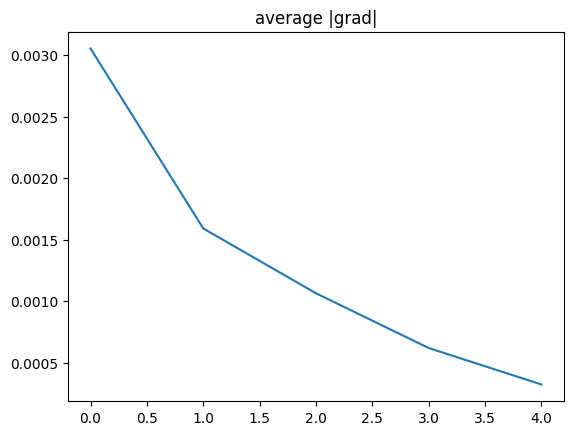

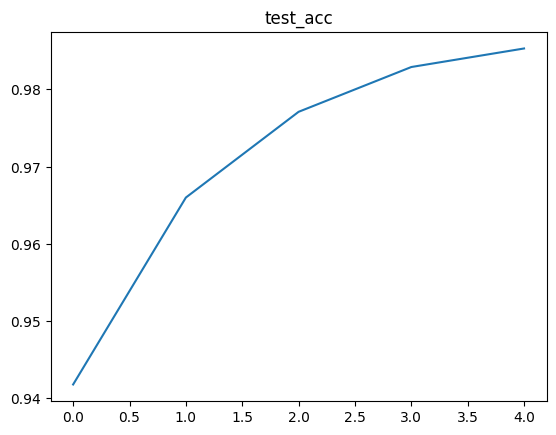

In [29]:
plt.figure()
plt.plot(hist_grad)
plt.title('average |grad|')
plt.show()

plt.figure()
plt.plot(hist_acc)
plt.title('test_acc')
plt.show()

for h in hooks:
    h.remove()